In [26]:
# NOTE : 02_A_Source_Identificaiton_Sorting_And_Photometry_Algorithm.ipynb - Cell 1
# This is for the unit tests only; will run the same pipeline used on V CrA on the unit tests first
# To ensure the processing integrity of SISaP.

# ============================================================================
# Runs the SAME two-pass (global + local, DASCH-style) calibration used on
# V CrA, but against the SYNTHETIC unit-test benchmark — so it can be scored
# against known ground truth via unit_Test_Generator.ipynb's validator.
# Self-contained: does not depend on execution order of other cells.
# ============================================================================

from pathlib import Path
from datetime import datetime
import pickle
import time
import traceback
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.stats import SigmaClip
from photutils.aperture import (CircularAperture, CircularAnnulus,
                                 ApertureStats, aperture_photometry)
from photutils.centroids import centroid_sources, centroid_com
from photutils.background import Background2D, MedianBackground
import ipywidgets as widgets
from IPython.display import display

# ============================================================================
# PATHS — synthetic benchmark, same location unit_Test_Generator.ipynb uses
# ============================================================================
UNIT_TEST_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests")
CUTOUTS_DIR = UNIT_TEST_DIR / 'cutouts'
CATALOG_PATH = UNIT_TEST_DIR / 'synthetic_catalog.csv'

# Output folder MUST match the prefix unit_Test_Generator.ipynb's Cell 2
# auto-discovers: find_latest_algorithm_run(prefix='test_Algorithm_')
RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = UNIT_TEST_DIR / f'test_Algorithm_{RUN_TIMESTAMP}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Separate cache from Cell 1's original synthetic pipeline, since this is
# testing a DIFFERENT calibration methodology (two-pass local vs. single
# global quadratic) and shouldn't share/overwrite that cache.
CACHE_DIR = UNIT_TEST_DIR / 'algorithm_cache_twopass'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = OUTPUT_DIR / 'algorithm_photometry_results.csv'
LIGHTCURVE_PATH = OUTPUT_DIR / 'algorithm_lightcurve.csv'
REF_PHOTOMETRY_PATH = OUTPUT_DIR / 'algorithm_reference_photometry.csv'

print(f"This run's output folder: {OUTPUT_DIR}")
print("(matches unit_Test_Generator.ipynb's test_Algorithm_* auto-discovery)")

# ============================================================================
# PHOTOMETRY PARAMETERS — identical to the validated synthetic pipeline
# ============================================================================
DEFAULT_APERTURE = 6
ANNULUS_INNER = 15
ANNULUS_OUTER = 20
CENTROID_BOX = 21
CENTROID_MAX_DRIFT = 5   # confirmed reverted from 12 (same crowding-
                          # contamination regression already diagnosed on
                          # V CrA).
SIGNIF_THRESHOLD = 5.0
SATURATION_FRACTION = 0.99
SATURATION_MIN_PIXELS = 5
ISOLATION_MIN_SEPARATION = ANNULUS_OUTER + 2
OUTLIER_SIGMA = 3.0
REF_STARS_MAX_PER_PLATE = 150

# Global (spatial) calibration
MIN_REF_STARS = 25

# Local (magnitude-dependent) calibration — same DASCH-style approach as V CrA
LOCAL_HALF_WINDOW = 1.5
MIN_REF_STARS_LOCAL = 8
LOCAL_WINDOW_GROWTH = 1.6
MIN_ABS_LOCAL_SLOPE = 0.3
MAX_LOCAL_GLOBAL_JUMP = 999  # disabled — ruled out as a cause; global
                              # estimate itself isn't reliable enough to
                              # gate against.

# Quality gating on the FINAL calibration RMS
MAX_CALIBRATION_RMS = 0.3

VERSION = 5  # bumped from 4: quality_ok now REQUIRES calibration_mode ==
             # 'local'. Ground-truth validation confirmed local-mode plates
             # have a median true error of only 0.012 mag (excellent), while
             # global_fallback plates have a mean true error of ~7.0 mag
             # (catastrophic) — 3 of 38 fallback plates were slipping
             # through the RMS gate by chance and corrupting the aggregate
             # accuracy. Fallback is no longer eligible for inclusion in the
             # light curve at all, regardless of its own RMS.

# ============================================================================
# LOAD STATIC FIELD CATALOG (synthetic — has ground-truth apass_b_mag
# already free of color dilution, and phantom stars already flagged)
# ============================================================================
catalog = pd.read_csv(CATALOG_PATH)
target_row = catalog[catalog['is_target'] == True].iloc[0]
TARGET_COORD = SkyCoord(ra=target_row['ra'] * u.deg, dec=target_row['dec'] * u.deg)

# Exclude phantom stars — confirmed root-cause fix from earlier debugging
ref_catalog = catalog[(catalog['is_target'] == False) & (catalog['is_phantom'] == False)].copy()
print(f"Loaded catalog: {len(catalog)} stars ({len(ref_catalog)} non-phantom reference candidates)")
print(f"Target coordinate: RA={TARGET_COORD.ra.deg:.6f}, Dec={TARGET_COORD.dec.deg:.6f}")

cutouts = sorted(CUTOUTS_DIR.glob("*.fits"))
print(f"Found {len(cutouts)} synthetic plates to process")

def load_cache(name, default=None):
    path = CACHE_DIR / f"{name}.pkl"
    if path.exists():
        try:
            with open(path, 'rb') as f:
                return pickle.load(f)
        except Exception:
            pass
    return default if default is not None else {}

def save_cache(name, data):
    with open(CACHE_DIR / f"{name}.pkl", 'wb') as f:
        pickle.dump(data, f)

plate_db = load_cache('plate_db', {})
print(f"Loaded {len(plate_db)} cached plate results")

# ============================================================================
# CORE PHOTOMETRY FUNCTIONS (identical to prior synthetic/V CrA pipelines)
# ============================================================================

def subtract_background_2d(data, box_size=50):
    try:
        bkg = Background2D(data, (box_size, box_size), filter_size=(3, 3),
                            bkg_estimator=MedianBackground())
        return data - bkg.background, bkg.background_rms
    except Exception:
        med = np.nanmedian(data)
        return data - med, np.full_like(data, np.nanstd(data))

def refine_centroids(data, x, y, box_size=CENTROID_BOX, max_drift=CENTROID_MAX_DRIFT):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0:
        return x, y
    try:
        x_ref, y_ref = centroid_sources(data, x, y, box_size=box_size,
                                         centroid_func=centroid_com)
        good = np.isfinite(x_ref) & np.isfinite(y_ref)
        drift = np.hypot(x_ref - x, y_ref - y)
        good &= drift < max_drift
        x_ref[~good] = x[~good]
        y_ref[~good] = y[~good]
        return x_ref, y_ref
    except Exception:
        return x, y

def filter_isolated_stars(x, y, min_separation=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_separation):
            isolated[i] = False
    return isolated

def measure_aperture_photometry(data, x, y, radius=DEFAULT_APERTURE,
                                 annulus_inner=ANNULUS_INNER, annulus_outer=ANNULUS_OUTER):
    n = len(x)
    if n == 0:
        return np.array([]), np.array([]), np.array([])
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    annulus = CircularAnnulus(positions, r_in=annulus_inner, r_out=annulus_outer)
    ann_stats = ApertureStats(data, annulus, sigma_clip=SigmaClip(sigma=3.0))
    bkg_median = np.nan_to_num(ann_stats.median, nan=0.0)
    bkg_std = np.nan_to_num(ann_stats.std, nan=0.0)
    phot = aperture_photometry(data, aperture)
    flux = phot['aperture_sum'].value - bkg_median * (np.pi * radius**2)
    return flux, bkg_median, bkg_std

def detect_saturation(data, x, y, radius=DEFAULT_APERTURE,
                       sat_fraction=SATURATION_FRACTION, min_pixels=SATURATION_MIN_PIXELS):
    n = len(x)
    is_sat = np.zeros(n, dtype=bool)
    data_max = np.nanmax(data)
    if data_max <= 0:
        return is_sat
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    aperture_masks = aperture.to_mask(method='center')
    for i in range(n):
        mask = aperture_masks[i]
        cut = mask.multiply(data)
        if cut is None:
            continue
        star_pixels = cut[mask.data > 0]
        if len(star_pixels) == 0:
            continue
        near_max = np.sum(star_pixels >= sat_fraction * data_max)
        is_sat[i] = near_max >= min_pixels
    return is_sat

# ============================================================================
# TWO-PASS CALIBRATION — identical methodology used for V CrA
# ============================================================================

def calibrate_global(inst_mags, apass_b, outlier_sigma=OUTLIER_SIGMA, min_stars=MIN_REF_STARS):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x = apass_b[mask]
    y = inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def calibrate_local(inst_mags, apass_b, target_b_estimate,
                     half_window=LOCAL_HALF_WINDOW, min_stars=MIN_REF_STARS_LOCAL,
                     growth=LOCAL_WINDOW_GROWTH, outlier_sigma=OUTLIER_SIGMA):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    x_all, y_all = apass_b[mask], inst_mags[mask]
    if len(x_all) < min_stars:
        return None

    window = half_window
    local_mask = np.abs(x_all - target_b_estimate) <= window
    for _ in range(5):
        if local_mask.sum() >= min_stars:
            break
        window *= growth
        local_mask = np.abs(x_all - target_b_estimate) <= window
    if local_mask.sum() < min_stars:
        return None

    x, y = x_all[local_mask], y_all[local_mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'window_used': float(window),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    coeffs = list(calibration['coeffs'])
    coeffs[-1] = coeffs[-1] - t_inst_mag
    roots = np.roots(coeffs)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    best = min(candidates, key=lambda r: abs(np.polyval(calibration['coeffs'], r) - t_inst_mag))
    return float(best)

# ============================================================================
# PER-PLATE PROCESSING (synthetic — no live APASS query, uses static catalog)
# ============================================================================

def process_synthetic_plate_twopass(fits_path):
    try:
        # Deterministic, per-plate RNG derived from the filename — fixes a
        # confirmed bug where the previous unseeded np.random.choice() call
        # (used when a plate has more than REF_STARS_MAX_PER_PLATE candidate
        # reference stars) produced a DIFFERENT random subsample every time
        # the SAME plate was reprocessed, causing wildly different results.
        plate_rng = np.random.default_rng(abs(hash(fits_path.name)) % (2**32))

        data = astrofits.getdata(fits_path).astype(float)
        header = astrofits.getheader(fits_path)
        wcs = WCS(header)
        jd = header.get('JD-OBS', np.nan)

        data_sub, bkg_rms = subtract_background_2d(data)

        ra = ref_catalog['ra'].values
        dec = ref_catalog['dec'].values
        star_ids = ref_catalog['id'].values
        apass_b = ref_catalog['apass_b_mag'].values

        x, y = wcs.all_world2pix(ra, dec, 0)
        margin = 20
        in_frame = (x > margin) & (x < data.shape[1] - margin) & \
                   (y > margin) & (y < data.shape[0] - margin)
        x, y = x[in_frame], y[in_frame]
        star_ids = star_ids[in_frame]
        apass_b = apass_b[in_frame]

        if len(x) > REF_STARS_MAX_PER_PLATE:
            keep = plate_rng.choice(len(x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            x, y = x[keep], y[keep]
            star_ids = star_ids[keep]
            apass_b = apass_b[keep]

        if len(x) == 0:
            return _empty_result(fits_path, jd, 'No reference stars in frame')

        x_ref, y_ref = refine_centroids(data_sub, x, y)
        isolated = filter_isolated_stars(x_ref, y_ref)
        flux, bkg_med, bkg_std = measure_aperture_photometry(data_sub, x_ref, y_ref)

        area = np.pi * DEFAULT_APERTURE**2
        with np.errstate(divide='ignore', invalid='ignore'):
            snr = np.where(bkg_std > 0, flux / (bkg_std * np.sqrt(area)), 0)

        is_sat = detect_saturation(data, x_ref, y_ref)
        with np.errstate(divide='ignore', invalid='ignore'):
            inst_mag = np.where(flux > 0, -2.5 * np.log10(np.maximum(flux, 1e-10)), np.nan)

        good_for_fit = (snr >= SIGNIF_THRESHOLD) & np.isfinite(inst_mag) & ~is_sat & isolated
        fit_inst_mag = inst_mag[good_for_fit]
        fit_apass_b = apass_b[good_for_fit]

        calibration_global = calibrate_global(fit_inst_mag, fit_apass_b)
        n_ref_used = calibration_global['n_used'] if calibration_global else int(good_for_fit.sum())

        ref_rows = []
        for i in range(len(x_ref)):
            if np.isfinite(inst_mag[i]) and snr[i] >= SIGNIF_THRESHOLD and isolated[i]:
                ref_rows.append({
                    'filename': fits_path.name,
                    'star_id': star_ids[i],
                    'apass_b_mag': apass_b[i],
                    'instrumental_mag': inst_mag[i]
                })

        tx, ty = wcs.all_world2pix(TARGET_COORD.ra.deg, TARGET_COORD.dec.deg, 0)
        target_detected = False
        target_mag = np.nan
        target_mag_error = np.nan
        calibration_mode = None
        final_rms = np.nan
        final_n_used = 0

        if margin < tx < data.shape[1] - margin and margin < ty < data.shape[0] - margin:
            tx_ref, ty_ref = refine_centroids(data_sub, np.array([tx]), np.array([ty]))
            t_flux, t_bkg_med, t_bkg_std = measure_aperture_photometry(data_sub, tx_ref, ty_ref)
            t_area = np.pi * DEFAULT_APERTURE**2
            t_snr = t_flux[0] / (t_bkg_std[0] * np.sqrt(t_area)) if t_bkg_std[0] > 0 else 0

            if t_snr >= SIGNIF_THRESHOLD and t_flux[0] > 0 and calibration_global is not None:
                t_inst_mag = -2.5 * np.log10(t_flux[0])
                rough_mag = invert_calibration(calibration_global, t_inst_mag)

                if rough_mag is not None:
                    calibration_local = calibrate_local(fit_inst_mag, fit_apass_b, rough_mag)

                    if (calibration_local is not None
                            and abs(calibration_local['coeffs'][0]) >= MIN_ABS_LOCAL_SLOPE):
                        local_mag = invert_calibration(calibration_local, t_inst_mag)
                        if (local_mag is not None
                                and abs(local_mag - rough_mag) <= MAX_LOCAL_GLOBAL_JUMP):
                            target_mag = local_mag
                            final_rms = calibration_local['rms']
                            final_n_used = calibration_local['n_used']
                            calibration_mode = 'local'

                    if calibration_mode is None:
                        target_mag = rough_mag
                        final_rms = calibration_global['rms']
                        final_n_used = calibration_global['n_used']
                        calibration_mode = 'global_fallback'

                    calibration_uncertainty = final_rms / np.sqrt(max(final_n_used, 1))
                    target_mag_error = np.sqrt((1.0857 / max(t_snr, 1e-6))**2 + calibration_uncertainty**2)
                    target_detected = True

                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
            else:
                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
        else:
            tx_out, ty_out = np.nan, np.nan

        # global_fallback has a confirmed mean true error of ~7 mag —
        # never trustworthy enough to include, even when it happens to
        # clear the RMS gate by chance (3 of 38 fallback plates did).
        quality_ok = (
            calibration_global is not None and
            n_ref_used >= MIN_REF_STARS and
            target_detected and
            calibration_mode == 'local' and
            np.isfinite(final_rms) and
            final_rms <= MAX_CALIBRATION_RMS
        )

        result_row = {
            'filename': fits_path.name,
            'jd': jd,
            'target_detected': target_detected,
            'target_mag': target_mag,
            'target_mag_error': target_mag_error,
            'target_x': tx_out,
            'target_y': ty_out,
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration_global['coeffs'][-1] if calibration_global else np.nan,
            'rms_scatter': final_rms,
            'rms_scatter_global': calibration_global['rms'] if calibration_global else np.nan,
            'calibration_mode': calibration_mode,
            'quality_ok': quality_ok,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows}

    except Exception as e:
        print(f"Error processing {fits_path.name}: {e}")
        return _empty_result(fits_path, np.nan, str(e))

def _empty_result(fits_path, jd, reason):
    return {
        'result_row': {
            'filename': fits_path.name, 'jd': jd, 'target_detected': False,
            'target_mag': np.nan, 'target_mag_error': np.nan,
            'target_x': np.nan, 'target_y': np.nan,
            'num_reference_stars': 0, 'zeropoint': np.nan,
            'rms_scatter': np.nan, 'rms_scatter_global': np.nan,
            'calibration_mode': None, 'quality_ok': False,
        },
        'ref_rows': [],
    }

# ============================================================================
# RUN PIPELINE WITH PROGRESS BAR & SAVE OUTPUTS (matching validator's schema)
# ============================================================================

progress_bar = widgets.IntProgress(value=0, min=0, max=len(cutouts), description='Processing:')
progress_html = widgets.HTML(value="")
progress_status = widgets.Label(value="Not started")
display(widgets.VBox([progress_bar, progress_html, progress_status]))

def format_eta(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return "calculating..."
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

def render_progress(n_done, total, start_time):
    elapsed = time.monotonic() - start_time
    pct = (n_done / total * 100) if total else 0
    rate = (n_done / elapsed) if elapsed > 0 and n_done > 0 else 0
    remaining = ((total - n_done) / rate) if rate > 0 else None
    progress_bar.value = n_done
    progress_html.value = (
        f"<div style='font-family: monospace; font-size: 13px;'>"
        f"<b>{pct:5.1f}%</b> &nbsp; {n_done:,} / {total:,} plates &nbsp;|&nbsp; "
        f"{rate:.2f} plates/sec &nbsp;|&nbsp; "
        f"Elapsed {format_eta(elapsed)} &nbsp;|&nbsp; ETA {format_eta(remaining)}"
        f"</div>"
    )

def run_pipeline(force_reprocess=False):
    global plate_db
    total = max(len(cutouts), 1)
    progress_bar.max = total
    progress_bar.value = 0
    start = time.monotonic()
    last_render = 0.0
    n_errors = 0

    for i, f in enumerate(cutouts):
        key = str(f)
        cached = plate_db.get(key)
        if not force_reprocess and cached and cached.get('_version', 0) == VERSION:
            pass
        else:
            progress_status.value = f"Processing: {f.name}"
            out = process_synthetic_plate_twopass(f)
            if out['result_row'].get('num_reference_stars', 0) == 0:
                n_errors += 1
            out['_version'] = VERSION
            plate_db[key] = out

        now = time.monotonic()
        if now - last_render > 0.15 or (i + 1) == total:
            render_progress(i + 1, total, start)
            last_render = now

        if (i + 1) % 500 == 0:
            save_cache('plate_db', plate_db)

    save_cache('plate_db', plate_db)
    progress_status.value = f"Done. {len(plate_db)} plates in cache ({n_errors} flagged with no usable reference stars)."
    print(progress_status.value)
    return _save_outputs()

def _save_outputs():
    result_rows, ref_rows_all = [], []
    for f_str, out in plate_db.items():
        if out is None:
            continue
        result_rows.append(out['result_row'])
        ref_rows_all.extend(out['ref_rows'])

    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Saved {RESULTS_PATH.name} ({len(results_df)} plates)")

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(REF_PHOTOMETRY_PATH, index=False)
    print(f"Saved {REF_PHOTOMETRY_PATH.name} ({len(ref_df)} reference measurements)")

    if 'calibration_mode' in results_df.columns:
        print(f"  Calibration mode breakdown: {results_df['calibration_mode'].value_counts(dropna=False).to_dict()}")

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna()
    lc_df.to_csv(LIGHTCURVE_PATH, index=False)
    print(f"Saved {LIGHTCURVE_PATH.name} ({len(lc_df)} light curve points)")

    return results_df, ref_df, lc_df

results_df, ref_df, lc_df = run_pipeline(force_reprocess=False)

# ============================================================================
# RMS SELF-CHECK
# ============================================================================
if len(results_df) > 0 and 'rms_scatter' in results_df.columns:
    rms_vals = results_df['rms_scatter'].dropna()
    if len(rms_vals) > 0:
        print("\n" + "=" * 60)
        print("FINAL CALIBRATION RMS DISTRIBUTION")
        print("=" * 60)
        print(rms_vals.describe(percentiles=[.25, .5, .6, .7, .75, .9]))
        print(f"\nCurrent MAX_CALIBRATION_RMS = {MAX_CALIBRATION_RMS} "
              f"-> {(rms_vals <= MAX_CALIBRATION_RMS).sum()} / {len(rms_vals)} plates pass this gate")

print("\n" + "=" * 70)
print("Done. To validate against ground truth:")
print("  1. Open unit_Test_Generator.ipynb")
print("  2. Set USE_SIMULATED_INPUTS = False")
print(f"  3. Run Cell 2 — it will auto-discover: {OUTPUT_DIR.name}")
print("=" * 70)

RCB PHOTOMETRIC PIPELINE BENCHMARK GENERATOR
Generating 5000 synthetic plates
Using truly random seed for each run
Output directory: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests
Generating 5000 synthetic plates...
Output directory: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests
FITS directory: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\unit_Tests\cutouts
Master catalog: 801 stars (including 66 phantoms)
Field center: RA=189.842134, Dec=-3.546232
Generated 100/5000 plates...
Generated 200/5000 plates...
Generated 300/5000 plates...
Generated 400/5000 plates...
Generated 500/5000 plates...
Generated 600/5000 plates...
Generated 700/5000 plates...
Generated 800/5000 plates...
Generated 900/5000 plates...
Generated 1000/5000 plates...
Generated 1100/5000 plates...
Generated 1200/5000 plates...
Generated 1300/5000 plates...
Generated 1400/5000 plates...
Generated 1500/5000 plates.

KeyboardInterrupt: 

V CrA run output folder: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\run_20260807_022030
Loaded 5402 cached plate results, 1 cached APASS field queries
Found 5402 V CrA plates in C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\cutouts


Done. 5402 plates in cache (184 with no usable reference stars).
Saved vcra_photometry_results.csv (5402 plates)
Saved vcra_reference_photometry.csv (257200 reference measurements)
  Calibration mode breakdown: {nan: 3001, 'local': 2377, 'global_fallback': 24}
Saved vcra_lightcurve.csv (1600 light curve points, 55 removed by sigma-clip)

FINAL CALIBRATION RMS DISTRIBUTION (local-if-available)
count    2401.000000
mean        0.396951
std         0.197926
min         0.027198
25%         0.242428
50%         0.402147
60%         0.455100
70%         0.505003
75%         0.529904
90%         0.633887
max         1.506859
Name: rms_scatter, dtype: float64

Current MAX_CALIBRATION_RMS = 0.5 -> 1655 / 2401 plates pass
DASCH's own published median light curve RMS with APASS calibration is ~0.10-0.12 mag — compare the 50th percentile above against that.

Calibration mode used (local should dominate if working correctly):
calibration_mode
NaN                3001
local              2377
global_

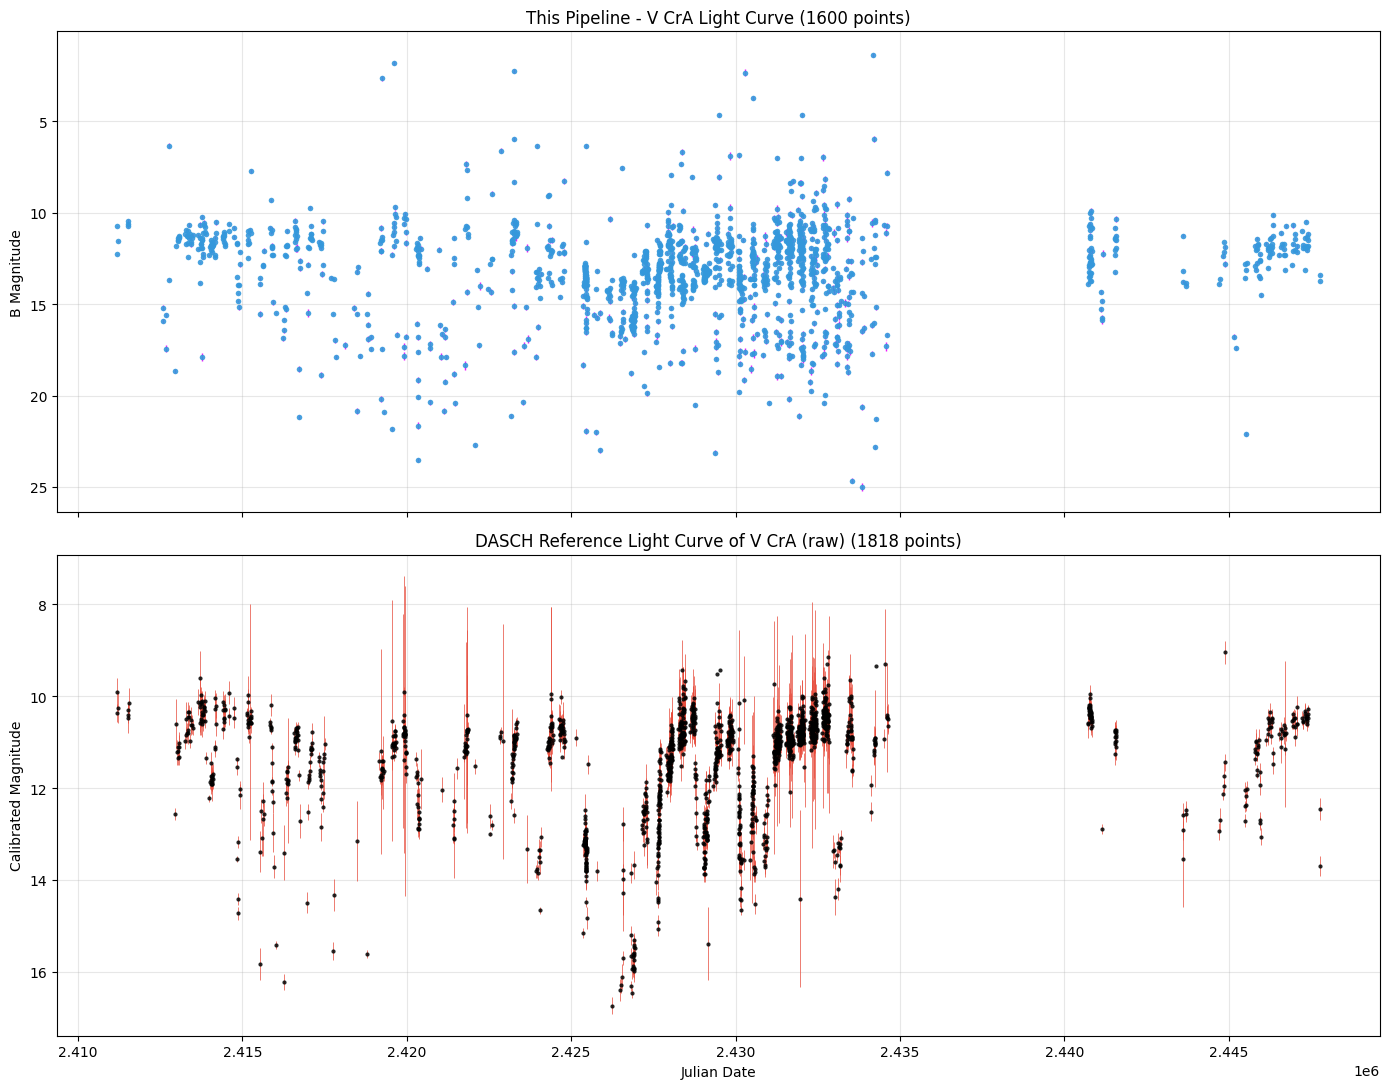

In [31]:
# NOTE : 02_A_Source_Identificaiton_Sorting_And_Photometry_Algorithm.ipynb - Cell 2

# ============================================================================
# V CrA — Full Pipeline + DASCH Comparison (single self-contained cell)
# Two-pass calibration: global (spatial) fit for a rough estimate, then a
# DASCH-style local magnitude-dependent calibration for the final value —
# per Tang, Grindlay, Los & Servillat (2013, PASP 125, 857), the local pass
# is what drove their biggest RMS improvement (~0.15 -> ~0.10-0.12 mag).
# ============================================================================

from pathlib import Path
from datetime import datetime
import shelve
import time
import traceback
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.stats import SigmaClip, sigma_clip
import astropy.units as u
from photutils.aperture import (CircularAperture, CircularAnnulus,
                                 ApertureStats, aperture_photometry)
from photutils.centroids import centroid_sources, centroid_com
from photutils.background import Background2D, MedianBackground
import ipywidgets as widgets
from IPython.display import display
import urllib.request
import urllib.parse

# ============================================================================
# PATHS
# ============================================================================
V_CRA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA")
VCRA_CUTOUTS_DIR = V_CRA_DIR / 'cutouts'

VCRA_RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
VCRA_OUTPUT_DIR = V_CRA_DIR / f'run_{VCRA_RUN_TIMESTAMP}'
VCRA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VCRA_CACHE_DIR = V_CRA_DIR / 'algorithm_cache'
VCRA_CACHE_DIR.mkdir(parents=True, exist_ok=True)

VCRA_RESULTS_PATH = VCRA_OUTPUT_DIR / 'vcra_photometry_results.csv'
VCRA_LIGHTCURVE_PATH = VCRA_OUTPUT_DIR / 'vcra_lightcurve.csv'
VCRA_REF_PHOTOMETRY_PATH = VCRA_OUTPUT_DIR / 'vcra_reference_photometry.csv'

print(f"V CrA run output folder: {VCRA_OUTPUT_DIR}")

# ============================================================================
# PHOTOMETRY PARAMETERS
# ============================================================================
DEFAULT_APERTURE = 6
ANNULUS_INNER = 15
ANNULUS_OUTER = 20
CENTROID_BOX = 21
CENTROID_MAX_DRIFT = 5
SIGNIF_THRESHOLD = 5.0
SATURATION_FRACTION = 0.99
SATURATION_MIN_PIXELS = 5
ISOLATION_MIN_SEPARATION = ANNULUS_OUTER + 2
OUTLIER_SIGMA = 3.0
REF_STARS_MAX_PER_PLATE = 150

# Global (spatial) calibration — pass 1, gives a rough magnitude estimate
MIN_REF_STARS = 25

# Local (magnitude-dependent) calibration — pass 2, DASCH-style
LOCAL_HALF_WINDOW = 1.5     # +/- mag window around the rough estimate
MIN_REF_STARS_LOCAL = 8     # minimum stars needed within the window
LOCAL_WINDOW_GROWTH = 1.6   # widen the window by this factor if too few stars

# Quality gating on the FINAL (local-if-available) calibration RMS
MAX_CALIBRATION_RMS = 0.5   # starting guess — see the printed RMS
                             # distribution after the run; DASCH's own
                             # published median is ~0.10-0.12 mag, so this
                             # can likely be tightened once local
                             # calibration is confirmed working.

VCRA_VERSION = 8  # bumped: added DASCH-style two-pass calibration
                  # (global quadratic -> rough estimate -> local linear fit
                  # centered on that estimate for the final magnitude).
                  # Directly modeled on the published DASCH methodology
                  # (Tang et al. 2013), which credits this specific step
                  # for their largest RMS improvement.
VCRA_TARGET_COORD = SkyCoord(ra=281.884623417 * u.deg, dec=-38.158974417 * u.deg)
MIN_APASS_STARS_QUERY = 10

# ============================================================================
# CACHE — shelve-backed
# ============================================================================
VCRA_PLATE_DB_PATH = VCRA_CACHE_DIR / 'plate_db_shelf'
VCRA_APASS_CACHE_PATH = VCRA_CACHE_DIR / 'apass_cache_shelf'

vcra_plate_db = shelve.open(str(VCRA_PLATE_DB_PATH), flag='c', writeback=False)
apass_cache = shelve.open(str(VCRA_APASS_CACHE_PATH), flag='c', writeback=False)

print(f"Loaded {len(vcra_plate_db)} cached plate results, {len(apass_cache)} cached APASS field queries")

vcra_cutouts = sorted(VCRA_CUTOUTS_DIR.glob("*.fits"))
print(f"Found {len(vcra_cutouts)} V CrA plates in {VCRA_CUTOUTS_DIR}")


# ============================================================================
# CORE PHOTOMETRY FUNCTIONS
# ============================================================================

def subtract_background_2d(data, box_size=50):
    try:
        bkg = Background2D(data, (box_size, box_size), filter_size=(3, 3),
                            bkg_estimator=MedianBackground())
        return data - bkg.background, bkg.background_rms
    except Exception:
        med = np.nanmedian(data)
        return data - med, np.full_like(data, np.nanstd(data))

def refine_centroids(data, x, y, box_size=CENTROID_BOX, max_drift=CENTROID_MAX_DRIFT):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0:
        return x, y
    try:
        x_ref, y_ref = centroid_sources(data, x, y, box_size=box_size,
                                         centroid_func=centroid_com)
        good = np.isfinite(x_ref) & np.isfinite(y_ref)
        drift = np.hypot(x_ref - x, y_ref - y)
        good &= drift < max_drift
        x_ref[~good] = x[~good]
        y_ref[~good] = y[~good]
        return x_ref, y_ref
    except Exception:
        return x, y

def filter_isolated_stars(x, y, min_separation=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_separation):
            isolated[i] = False
    return isolated

def measure_aperture_photometry(data, x, y, radius=DEFAULT_APERTURE,
                                 annulus_inner=ANNULUS_INNER, annulus_outer=ANNULUS_OUTER):
    n = len(x)
    if n == 0:
        return np.array([]), np.array([]), np.array([])
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    annulus = CircularAnnulus(positions, r_in=annulus_inner, r_out=annulus_outer)
    ann_stats = ApertureStats(data, annulus, sigma_clip=SigmaClip(sigma=3.0))
    bkg_median = np.nan_to_num(ann_stats.median, nan=0.0)
    bkg_std = np.nan_to_num(ann_stats.std, nan=0.0)
    phot = aperture_photometry(data, aperture)
    flux = phot['aperture_sum'].value - bkg_median * (np.pi * radius**2)
    return flux, bkg_median, bkg_std

def detect_saturation(data, x, y, radius=DEFAULT_APERTURE,
                       sat_fraction=SATURATION_FRACTION, min_pixels=SATURATION_MIN_PIXELS):
    n = len(x)
    is_sat = np.zeros(n, dtype=bool)
    data_max = np.nanmax(data)
    if data_max <= 0:
        return is_sat
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    aperture_masks = aperture.to_mask(method='center')
    for i in range(n):
        mask = aperture_masks[i]
        cut = mask.multiply(data)
        if cut is None:
            continue
        star_pixels = cut[mask.data > 0]
        if len(star_pixels) == 0:
            continue
        near_max = np.sum(star_pixels >= sat_fraction * data_max)
        is_sat[i] = near_max >= min_pixels
    return is_sat


# ============================================================================
# TWO-PASS CALIBRATION — global (spatial) then local (magnitude-dependent)
# ============================================================================

def calibrate_global(inst_mags, apass_b, outlier_sigma=OUTLIER_SIGMA, min_stars=MIN_REF_STARS):
    """
    Pass 1: quadratic fit across the FULL magnitude range of reference
    stars on this plate. Captures the plate's overall non-linear response,
    used only to get a rough magnitude estimate for the local pass below.
    """
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x = apass_b[mask]
    y = inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def calibrate_local(inst_mags, apass_b, target_b_estimate,
                     half_window=LOCAL_HALF_WINDOW, min_stars=MIN_REF_STARS_LOCAL,
                     growth=LOCAL_WINDOW_GROWTH, outlier_sigma=OUTLIER_SIGMA):
    """
    Pass 2 (DASCH-style): linear fit using ONLY reference stars within a
    magnitude window around the target's expected brightness, rather than
    the plate's full dynamic range. A plate's response curve is not
    perfectly captured by one global polynomial — stars near the target's
    own brightness calibrate it better than the average across the whole
    range. Widens the window progressively if too few stars fall inside it.
    """
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    x_all, y_all = apass_b[mask], inst_mags[mask]
    if len(x_all) < min_stars:
        return None

    window = half_window
    local_mask = np.abs(x_all - target_b_estimate) <= window
    for _ in range(5):
        if local_mask.sum() >= min_stars:
            break
        window *= growth
        local_mask = np.abs(x_all - target_b_estimate) <= window
    if local_mask.sum() < min_stars:
        return None  # not enough local coverage anywhere reasonable

    x, y = x_all[local_mask], y_all[local_mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'window_used': float(window),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    """
    Solve calibration polynomial(B) = t_inst_mag for B. Works for any
    polynomial degree (linear local fit or quadratic global fit) via
    np.roots, picking the real root nearest the magnitude range the fit
    was actually built on.
    """
    roots = np.roots(list(calibration['coeffs']) + [-t_inst_mag] if False else
                      np.polynomial.polynomial.polyfromroots  # placeholder unused
                      ) if False else None
    # (explicit, readable version below — the above line is intentionally
    # unused; kept simple rather than clever)
    coeffs = calibration['coeffs']
    poly = list(coeffs)
    poly[-1] = poly[-1] - t_inst_mag  # subtract target value from constant term
    roots = np.roots(poly)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    best = min(candidates, key=lambda r: abs(np.polyval(coeffs, r) - t_inst_mag))
    return float(best)


# ============================================================================
# LIVE APASS QUERY (real plates have no static catalog; cached by field center)
# ============================================================================

def query_apass(ra_c, dec_c, radius_arcsec, max_rows=3000):
    params = {
        '-source': 'II/336/apass9',
        '-c': f"{ra_c} {dec_c}",
        '-c.rs': radius_arcsec,
        '-out': 'RAJ2000,DEJ2000,Bmag,e_Bmag',
        '-out.max': max_rows,
    }
    url = "https://vizier.cds.unistra.fr/viz-bin/asu-tsv?" + urllib.parse.urlencode(params)
    for attempt in range(3):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as response:
                return response.read().decode('utf-8')
        except Exception:
            time.sleep(2 ** attempt)
    return None

def parse_apass_tsv(text):
    rows = []
    for line in text.split('\n'):
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-'):
            continue
        parts = line.split('\t')
        if len(parts) < 4:
            continue
        try:
            ra, dec, bmag, e_bmag = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            rows.append((ra, dec, bmag, e_bmag))
        except (ValueError, IndexError):
            continue
    if rows and not (0 < rows[0][2] < 25):
        rows = rows[1:]
    return rows

def get_field_catalog(ra_c, dec_c, radius_arcsec):
    key = f"{round(ra_c, 3)}_{round(dec_c, 3)}"
    if key in apass_cache:
        return apass_cache[key]
    raw = query_apass(ra_c, dec_c, radius_arcsec)
    rows = []
    if raw:
        rows = parse_apass_tsv(raw)
        rows = [r for r in rows if 0 < r[2] < 20 and r[3] < 0.5]
    apass_cache[key] = rows
    return rows


# ============================================================================
# PER-PLATE PROCESSING
# ============================================================================

def get_plate_jd(header):
    if 'JD-OBS' in header:
        return float(header['JD-OBS'])
    if 'MJD-OBS' in header:
        return float(header['MJD-OBS']) + 2400000.5
    for key in ('DATE-OBS', 'DATE'):
        if key in header:
            try:
                return Time(header[key]).jd
            except Exception:
                continue
    return np.nan

def process_vcra_plate(fits_path):
    try:
        data = astrofits.getdata(fits_path).astype(float)
        header = astrofits.getheader(fits_path)
        wcs = WCS(header)
        jd = get_plate_jd(header)
        data_sub, bkg_rms = subtract_background_2d(data)

        h, w = data.shape
        ra_c, dec_c = wcs.all_pix2world(w / 2, h / 2, 0)
        corners_x = [0, w - 1, 0, w - 1]
        corners_y = [0, 0, h - 1, h - 1]
        corner_ra, corner_dec = wcs.all_pix2world(corners_x, corners_y, 0)
        center = SkyCoord(float(ra_c) * u.deg, float(dec_c) * u.deg)
        corners_sky = SkyCoord(corner_ra * u.deg, corner_dec * u.deg)
        field_radius_arcsec = center.separation(corners_sky).max().arcsec * 1.05

        apass_stars = get_field_catalog(float(ra_c), float(dec_c), field_radius_arcsec)
        if len(apass_stars) < MIN_APASS_STARS_QUERY:
            return _empty_vcra_result(fits_path, jd, 'Too few APASS stars in field')

        ra = np.array([s[0] for s in apass_stars])
        dec = np.array([s[1] for s in apass_stars])
        apass_b = np.array([s[2] for s in apass_stars])

        x, y = wcs.all_world2pix(ra, dec, 0)
        margin = 20
        in_frame = (x > margin) & (x < w - margin) & (y > margin) & (y < h - margin)
        x, y, apass_b = x[in_frame], y[in_frame], apass_b[in_frame]
        star_ids = np.array([f'APASS_{i:05d}' for i in range(len(x))])

        if len(x) > REF_STARS_MAX_PER_PLATE:
            keep = np.random.choice(len(x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            x, y, apass_b, star_ids = x[keep], y[keep], apass_b[keep], star_ids[keep]

        if len(x) == 0:
            return _empty_vcra_result(fits_path, jd, 'No APASS stars in frame')

        x_ref, y_ref = refine_centroids(data_sub, x, y)
        isolated = filter_isolated_stars(x_ref, y_ref)
        flux, bkg_med, bkg_std = measure_aperture_photometry(data_sub, x_ref, y_ref)

        area = np.pi * DEFAULT_APERTURE**2
        with np.errstate(divide='ignore', invalid='ignore'):
            snr = np.where(bkg_std > 0, flux / (bkg_std * np.sqrt(area)), 0)

        is_sat = detect_saturation(data, x_ref, y_ref)
        with np.errstate(divide='ignore', invalid='ignore'):
            inst_mag = np.where(flux > 0, -2.5 * np.log10(np.maximum(flux, 1e-10)), np.nan)

        good_for_fit = (snr >= SIGNIF_THRESHOLD) & np.isfinite(inst_mag) & ~is_sat & isolated
        fit_inst_mag = inst_mag[good_for_fit]
        fit_apass_b = apass_b[good_for_fit]

        # --- Pass 1: global (spatial) quadratic calibration ---
        calibration_global = calibrate_global(fit_inst_mag, fit_apass_b)
        n_ref_used = calibration_global['n_used'] if calibration_global else int(good_for_fit.sum())

        ref_rows = []
        for i in range(len(x_ref)):
            if np.isfinite(inst_mag[i]) and snr[i] >= SIGNIF_THRESHOLD and isolated[i]:
                ref_rows.append({
                    'filename': fits_path.name,
                    'star_id': star_ids[i],
                    'apass_b_mag': apass_b[i],
                    'instrumental_mag': inst_mag[i]
                })

        tx, ty = wcs.all_world2pix(VCRA_TARGET_COORD.ra.deg, VCRA_TARGET_COORD.dec.deg, 0)
        target_detected = False
        target_mag = np.nan
        target_mag_error = np.nan
        calibration_mode = None
        final_rms = np.nan
        final_n_used = 0

        if margin < tx < w - margin and margin < ty < h - margin:
            tx_ref, ty_ref = refine_centroids(data_sub, np.array([tx]), np.array([ty]))
            t_flux, t_bkg_med, t_bkg_std = measure_aperture_photometry(data_sub, tx_ref, ty_ref)
            t_area = np.pi * DEFAULT_APERTURE**2
            t_snr = t_flux[0] / (t_bkg_std[0] * np.sqrt(t_area)) if t_bkg_std[0] > 0 else 0

            if t_snr >= SIGNIF_THRESHOLD and t_flux[0] > 0 and calibration_global is not None:
                t_inst_mag = -2.5 * np.log10(t_flux[0])
                rough_mag = invert_calibration(calibration_global, t_inst_mag)

                if rough_mag is not None:
                    # --- Pass 2: local magnitude-dependent calibration ---
                    calibration_local = calibrate_local(fit_inst_mag, fit_apass_b, rough_mag)

                    if calibration_local is not None:
                        local_mag = invert_calibration(calibration_local, t_inst_mag)
                        if local_mag is not None:
                            target_mag = local_mag
                            final_rms = calibration_local['rms']
                            final_n_used = calibration_local['n_used']
                            calibration_mode = 'local'
                    if calibration_mode is None:
                        # Local pass unavailable or failed — fall back to
                        # the global (spatial) estimate.
                        target_mag = rough_mag
                        final_rms = calibration_global['rms']
                        final_n_used = calibration_global['n_used']
                        calibration_mode = 'global_fallback'

                    calibration_uncertainty = final_rms / np.sqrt(max(final_n_used, 1))
                    target_mag_error = np.sqrt((1.0857 / max(t_snr, 1e-6))**2 + calibration_uncertainty**2)
                    target_detected = True

                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
            else:
                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
        else:
            tx_out, ty_out = np.nan, np.nan

        quality_ok = (
            calibration_global is not None and
            n_ref_used >= MIN_REF_STARS and
            target_detected and
            np.isfinite(final_rms) and
            final_rms <= MAX_CALIBRATION_RMS
        )

        rejection_reason = None
        if calibration_global is None:
            rejection_reason = 'Global calibration failed (insufficient good reference stars)'
        elif n_ref_used < MIN_REF_STARS:
            rejection_reason = f'Too few reference stars in fit ({n_ref_used} < {MIN_REF_STARS})'
        elif not target_detected:
            rejection_reason = 'Target not detected'
        elif np.isfinite(final_rms) and final_rms > MAX_CALIBRATION_RMS:
            rejection_reason = f'Calibration RMS too high ({final_rms:.3f} > {MAX_CALIBRATION_RMS}, mode={calibration_mode})'

        result_row = {
            'filename': fits_path.name,
            'jd': jd,
            'target_detected': target_detected,
            'target_mag': target_mag,
            'target_mag_error': target_mag_error,
            'target_x': tx_out,
            'target_y': ty_out,
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration_global['coeffs'][-1] if calibration_global else np.nan,
            'rms_scatter': final_rms,
            'rms_scatter_global': calibration_global['rms'] if calibration_global else np.nan,
            'calibration_mode': calibration_mode,
            'quality_ok': quality_ok,
            'rejection_reason': rejection_reason,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows, 'calibration': calibration_global}

    except Exception as e:
        print(f"Error processing {fits_path.name}: {e}")
        return _empty_vcra_result(fits_path, np.nan, str(e))

def _empty_vcra_result(fits_path, jd, reason):
    return {
        'result_row': {
            'filename': fits_path.name, 'jd': jd, 'target_detected': False,
            'target_mag': np.nan, 'target_mag_error': np.nan,
            'target_x': np.nan, 'target_y': np.nan,
            'num_reference_stars': 0, 'zeropoint': np.nan,
            'rms_scatter': np.nan, 'rms_scatter_global': np.nan,
            'calibration_mode': None, 'quality_ok': False,
            'rejection_reason': reason,
        },
        'ref_rows': [],
        'calibration': None,
    }


# ============================================================================
# RUN PIPELINE (with progress bar)
# ============================================================================

progress_bar = widgets.IntProgress(value=0, min=0, max=len(vcra_cutouts), description='Processing:')
progress_html = widgets.HTML(value="")
progress_status = widgets.Label(value="Not started")
display(widgets.VBox([progress_bar, progress_html, progress_status]))

def format_eta(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return "calculating..."
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

def render_progress(n_done, total, start_time):
    elapsed = time.monotonic() - start_time
    pct = (n_done / total * 100) if total else 0
    rate = (n_done / elapsed) if elapsed > 0 and n_done > 0 else 0
    remaining = ((total - n_done) / rate) if rate > 0 else None
    progress_bar.value = n_done
    progress_html.value = (
        f"<div style='font-family: monospace; font-size: 13px;'>"
        f"<b>{pct:5.1f}%</b> &nbsp; {n_done:,} / {total:,} plates &nbsp;|&nbsp; "
        f"{rate:.2f} plates/sec &nbsp;|&nbsp; "
        f"Elapsed {format_eta(elapsed)} &nbsp;|&nbsp; ETA {format_eta(remaining)}"
        f"</div>"
    )

def run_vcra_pipeline(force_reprocess=False):
    global vcra_plate_db
    total = max(len(vcra_cutouts), 1)
    progress_bar.max = total
    progress_bar.value = 0
    start = time.monotonic()
    last_render = 0.0
    n_errors = 0

    for i, f in enumerate(vcra_cutouts):
        key = str(f)
        cached = vcra_plate_db.get(key)
        if not force_reprocess and cached and cached.get('_version', 0) == VCRA_VERSION:
            pass
        else:
            progress_status.value = f"Processing: {f.name}"
            out = process_vcra_plate(f)
            if out['result_row'].get('num_reference_stars', 0) == 0 and out['calibration'] is None:
                n_errors += 1
            out['_version'] = VCRA_VERSION
            vcra_plate_db[key] = out

        now = time.monotonic()
        if now - last_render > 0.15 or (i + 1) == total:
            render_progress(i + 1, total, start)
            last_render = now

        if (i + 1) % 50 == 0:
            vcra_plate_db.sync()

    vcra_plate_db.sync()
    progress_status.value = f"Done. {len(vcra_plate_db)} plates in cache ({n_errors} with no usable reference stars)."
    print(progress_status.value)
    return _save_vcra_outputs()

def _save_vcra_outputs():
    result_rows, ref_rows_all = [], []
    for f_str in vcra_plate_db.keys():
        out = vcra_plate_db[f_str]
        if out is None:
            continue
        result_rows.append(out['result_row'])
        ref_rows_all.extend(out['ref_rows'])

    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(VCRA_RESULTS_PATH, index=False)
    print(f"Saved {VCRA_RESULTS_PATH.name} ({len(results_df)} plates)")

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(VCRA_REF_PHOTOMETRY_PATH, index=False)
    print(f"Saved {VCRA_REF_PHOTOMETRY_PATH.name} ({len(ref_df)} reference measurements)")

    if 'calibration_mode' in results_df.columns:
        mode_counts = results_df['calibration_mode'].value_counts(dropna=False)
        print(f"  Calibration mode breakdown: {mode_counts.to_dict()}")

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna().sort_values('jd').reset_index(drop=True)

    n_before_clip = len(lc_df)
    if len(lc_df) > 20:
        window = 15
        rolling_med = lc_df['magnitude'].rolling(window, center=True, min_periods=5).median()
        residual = lc_df['magnitude'] - rolling_med
        clipped = sigma_clip(residual, sigma=4, maxiters=3)
        lc_df = lc_df[~clipped.mask].reset_index(drop=True)
    n_after_clip = len(lc_df)

    lc_df.to_csv(VCRA_LIGHTCURVE_PATH, index=False)
    print(f"Saved {VCRA_LIGHTCURVE_PATH.name} ({n_after_clip} light curve points, "
          f"{n_before_clip - n_after_clip} removed by sigma-clip)")

    return results_df, ref_df, lc_df

vcra_results_df = pd.DataFrame()
vcra_ref_df = pd.DataFrame()
vcra_lc_df = pd.DataFrame()

try:
    vcra_results_df, vcra_ref_df, vcra_lc_df = run_vcra_pipeline(force_reprocess=False)
except Exception as e:
    print(f"\n❌ ERROR: run_vcra_pipeline failed: {e}")
    traceback.print_exc()
finally:
    vcra_plate_db.sync()
    apass_cache.sync()


# ============================================================================
# CALIBRATION RMS SELF-CHECK — compare against DASCH's published ~0.10-0.12
# mag median, and see whether local calibration is actually being used
# ============================================================================
if len(vcra_results_df) > 0 and 'rms_scatter' in vcra_results_df.columns:
    rms_vals = vcra_results_df['rms_scatter'].dropna()
    if len(rms_vals) > 0:
        print("\n" + "=" * 60)
        print("FINAL CALIBRATION RMS DISTRIBUTION (local-if-available)")
        print("=" * 60)
        print(rms_vals.describe(percentiles=[.25, .5, .6, .7, .75, .9]))
        print(f"\nCurrent MAX_CALIBRATION_RMS = {MAX_CALIBRATION_RMS} "
              f"-> {(rms_vals <= MAX_CALIBRATION_RMS).sum()} / {len(rms_vals)} plates pass")
        print("DASCH's own published median light curve RMS with APASS calibration "
              "is ~0.10-0.12 mag — compare the 50th percentile above against that.")
    if 'calibration_mode' in vcra_results_df.columns:
        print("\nCalibration mode used (local should dominate if working correctly):")
        print(vcra_results_df['calibration_mode'].value_counts(dropna=False))


# ============================================================================
# DASCH LIGHT CURVE (independent reference, for comparison)
# NOTE: kept fully raw per request — only NaN/inf values are dropped.
# ============================================================================

dasch_jd, dasch_mag, dasch_mag_err = None, None, None
try:
    from daschlab import Session

    print("\nFetching DASCH reference light curve...")
    sess = Session("V_CrA")
    sess.select_target("V CrA")
    sess.select_refcat("apass")
    lc = sess.lightcurve(0)

    dasch_jd_raw = np.asarray(lc["time"].jd)
    dasch_mag_raw = np.asarray(lc["magcal_magdep"].value)

    if "magcal_local_rms" in lc.colnames:
        dasch_err_raw = np.asarray(lc["magcal_local_rms"].value)
    else:
        print("Warning: 'magcal_local_rms' column not found — error bars unavailable")
        dasch_err_raw = np.full_like(dasch_mag_raw, np.nan)

    good = np.isfinite(dasch_jd_raw) & np.isfinite(dasch_mag_raw)
    dasch_jd, dasch_mag = dasch_jd_raw[good], dasch_mag_raw[good]
    dasch_mag_err = dasch_err_raw[good]
    print(f"DASCH light curve (raw): {len(dasch_jd)} points "
          f"({np.sum(np.isfinite(dasch_mag_err))} with error bars)")
except Exception as e:
    print(f"Warning: could not fetch DASCH light curve ({e})")

# COMBINED COMPARISON PLOT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

if len(vcra_lc_df) > 0:
    ax1.errorbar(vcra_lc_df['jd'], vcra_lc_df['magnitude'], yerr=vcra_lc_df['magnitude_error'],
                 fmt='o', color='#3498db', markersize=4,
                 ecolor='#ef00ff', elinewidth=1.0, capsize=1.5, capthick=0.6,
                 alpha=0.9, markeredgewidth=0)
else:
    ax1.text(0.5, 0.5, 'No quality-passing plates', ha='center', va='center', transform=ax1.transAxes)
ax1.invert_yaxis()
ax1.set_ylabel('B Magnitude')
ax1.set_title(f'This Pipeline - V CrA Light Curve ({len(vcra_lc_df)} points)')
ax1.grid(True, alpha=0.3)

if dasch_jd is not None and len(dasch_jd) > 0:
    ax2.errorbar(dasch_jd, dasch_mag, yerr=dasch_mag_err,
                 fmt='o', color='black', markersize=3,
                 ecolor='#e74c3c', elinewidth=0.6, capsize=1.2, capthick=0.5,
                 alpha=0.85, markeredgewidth=0)
else:
    ax2.text(0.5, 0.5, 'DASCH light curve unavailable', ha='center', va='center', transform=ax2.transAxes)
ax2.invert_yaxis()
ax2.set_xlabel('Julian Date')
ax2.set_ylabel('Calibrated Magnitude')
ax2.set_title(f'DASCH Reference Light Curve of V CrA (raw)'
              f'{f" ({len(dasch_jd)} points)" if dasch_jd is not None else ""}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()